# Electrones y positrones secundarios: figuras de la Sección 4.2 de la tesis (Campaña 1)

Este notebook regenera las figuras de los $e^\pm$ producidos por los fotones gamma de captura (Campaña 1: 16 energías
× 4 medios, $10^5$ neutrones por corrida, `QGSP_BERT_HP` sin $S(\alpha,\beta)$). Solo lee los resúmenes que produce
`procesar_electrones.py` (`resultados_electrones/`).

| Figura o tabla de la tesis | Contenido | Definición |
|---|---|---|
| Fig. 4.45 y Tabla E.1 | Pasos por proceso de los $e^\pm$ en el tanque | tanque estricto ($z\le1330$ mm) |
| Fig. 4.46 | Energía de los pasos limitados por `eIoni` (agua pura y 2.5 % NaCl) | ídem, $E\neq0$; 100 intervalos en 0–1.6 MeV |
| Fig. 4.47 y Tabla 4.18 | Ajuste fino del máximo del espectro de los pasos `Cerenkov` | ídem; gaussiana + fondo lineal en ±4.5 keV, intervalos de 0.04 keV |
| Tabla 4.19 | Pasos `Cerenkov` en la ventana del máximo | ídem; 259.6–268.6 keV |
| Figs. E.3 y E.4 | Energía de todos los pasos de los $e^\pm$ en el tanque (1 meV y 1 keV) | tanque ($z\le1330.05$ mm) |

Figuras nuevas: proceso que limita el paso según la energía del electrón, espectro de la energía inicial de los
$e^-$ y $e^+$, umbral Cherenkov del agua y del Pyrex, posición de los pasos Cherenkov en el Pyrex, y rendimientos
por captura.

**Cómo leer la columna de proceso.** El archivo registra el proceso que *limitó* el paso, no todos los procesos
que actuaron en él: la ionización continua actúa en todos los pasos. `Scintillation` es un paso de longitud cero
que Geant4 añade cuando el electrón se detiene (cuenta electrones detenidos, no luz).

In [1]:
import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, ".")
from procesar_electrones import E_UMBRAL_AGUA, E_UMBRAL_PYREX, ajuste_pico_cherenkov, umbral_cherenkov

RES = Path("resultados_electrones")
SALIDA = Path("figuras-electrones")
SALIDA.mkdir(exist_ok=True)

ENERGIAS = ["1meV", "2.5meV", "5meV", "7meV", "10meV", "25meV", "50meV", "80meV", "100meV",
            "300meV", "500meV", "700meV", "1000meV", "10000meV", "100000meV", "1000000meV"]
VALOR_MEV = np.array([1, 2.5, 5, 7, 10, 25, 50, 80, 100, 300, 500, 700, 1e3, 1e4, 1e5, 1e6])
ROTULO = dict(zip(ENERGIAS, ["1 meV", "2.5 meV", "5 meV", "7 meV", "10 meV", "25 meV", "50 meV", "80 meV",
                             "100 meV", "300 meV", "500 meV", "700 meV", "1 eV", "10 eV", "100 eV", "1 keV"]))
E4 = ["1meV", "100meV", "1000meV", "1000000meV"]
E5 = ["1meV", "10meV", "100meV", "1000meV", "1000000meV"]
E7 = ["1meV", "10meV", "100meV", "1000meV", "10000meV", "100000meV", "1000000meV"]
COLOR_E = dict(zip(E7, ["red", "green", "purple", "darkorange", "blue", "brown", "gray"]))
MEDIOS = ["Agua-pura", "Agua+2.5NaCl", "Agua+5NaCl", "Agua+10NaCl"]
NOMBRE = dict(zip(MEDIOS, ["Agua pura", "Agua + 2.5 % NaCl", "Agua + 5 % NaCl", "Agua + 10 % NaCl"]))
COLOR = dict(zip(MEDIOS, ["red", "green", "purple", "darkorange"]))
MARCA = dict(zip(MEDIOS, ["o", "s", "^", "D"]))
ESTILO = dict(zip(MEDIOS, ["-", "--", "-.", ":"]))
N_TESIS = dict(zip(MEDIOS, [1.3330, 1.3397, 1.3436, 1.3594]))     # Tabla 4.17 (literatura)

plt.rcParams.update({"font.family": "serif", "font.size": 14, "axes.labelsize": 17,
                     "legend.fontsize": 12, "axes.linewidth": 1.1})

R = {(e, m): json.loads((RES / e / m / "resumen_electrones.json").read_text()) for e in ENERGIAS for m in MEDIOS}
with open("../campana-1_neutrones-monoenergeticos_seccion-4.2/resultados/resumen_campana.tsv") as f:
    CAP = {(r["energia"], r["medio"]): int(r["capturas"]) for r in csv.DictReader(f, delimiter="\t")}


def guardar(fig, nombre):
    fig.savefig(SALIDA / f"{nombre}.pdf", bbox_inches="tight")
    fig.savefig(SALIDA / f"{nombre}.png", dpi=200, bbox_inches="tight")
    plt.show()


def regiones(ax, y_texto=None):
    for x in (10, 100, 1000):
        ax.axvline(x, color="0.35", ls="--", lw=1.2)
    if y_texto is not None:
        for x, t in [(3, "Fríos"), (30, "Térmicos"), (300, "Epitérmicos"), (3e4, "Intermedios")]:
            ax.text(x, y_texto, t, ha="center", va="bottom", fontsize=13, fontweight="bold",
                    transform=ax.get_xaxis_transform())


def eje_energia(ax):
    ax.set_xscale("log")
    ax.set_xlabel(r"Energía inicial del neutrón, $E_n$ [meV]")


def conteo(e, m, proc, zona="tanque_estricto"):
    return R[(e, m)]["procesos"][proc][zona]


def centros(h):
    return h["rango"][0] + (np.arange(len(h["conteos"])) + 0.5) * h["ancho"]


def reagrupar(h, k):
    c = np.array(h["conteos"], float)
    n = len(c) // k
    c = c[:n * k].reshape(n, k).sum(1)
    return h["rango"][0] + (np.arange(n) + 0.5) * h["ancho"] * k, c

## Fig. 4.45 (y Tabla E.1): pasos por proceso de los $e^\pm$ en el tanque

Se omite `Scintillation` (pasos de longitud cero al detenerse el electrón) y `annihil` (aniquilación de los
$e^+$, 0–10 pasos por corrida). Los valores se leen de los resúmenes, lo que corrige las ocho celdas mal
transcritas de la Tabla E.1 (ver la verificación al final).

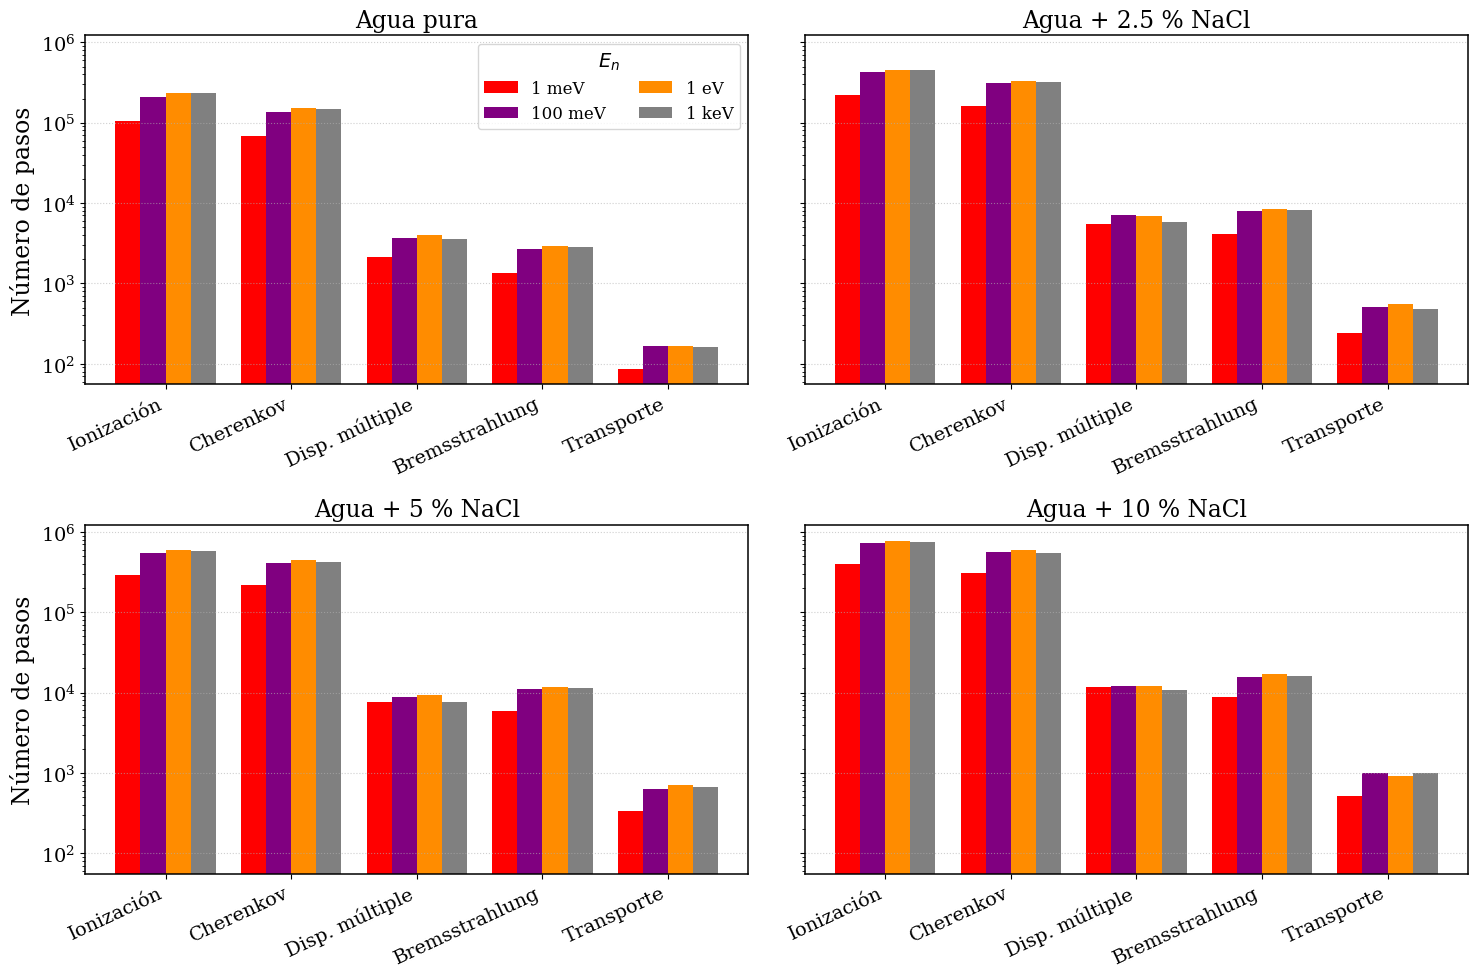

In [2]:
PROC = [("eIoni", "Ionización"), ("Cerenkov", "Cherenkov"), ("msc", "Disp. múltiple"), ("eBrem", "Bremsstrahlung"),
        ("Transportation", "Transporte")]
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
ancho = 0.2
for ax, m in zip(axs.flat, MEDIOS):
    x = np.arange(len(PROC))
    for k, e in enumerate(E4):
        ax.bar(x + (k - 1.5) * ancho, [conteo(e, m, p) for p, _ in PROC], ancho, color=COLOR_E[e], label=ROTULO[e])
    ax.set_xticks(x, [n for _, n in PROC], rotation=25, ha="right")
    ax.set_yscale("log")
    ax.set_title(NOMBRE[m])
    ax.grid(axis="y", ls=":", alpha=0.6)
for ax in axs[:, 0]:
    ax.set_ylabel("Número de pasos")
axs[0, 0].legend(title=r"$E_n$", ncol=2)
fig.tight_layout()
guardar(fig, "fig_4_45_procesos_tanque")

## Nueva: pasos por captura frente a la energía del neutrón

Los conteos absolutos de la Fig. 4.45 siguen al número de capturas en el tanque. Por captura, los rendimientos
son casi independientes de $E_n$ y dependen solo del medio.

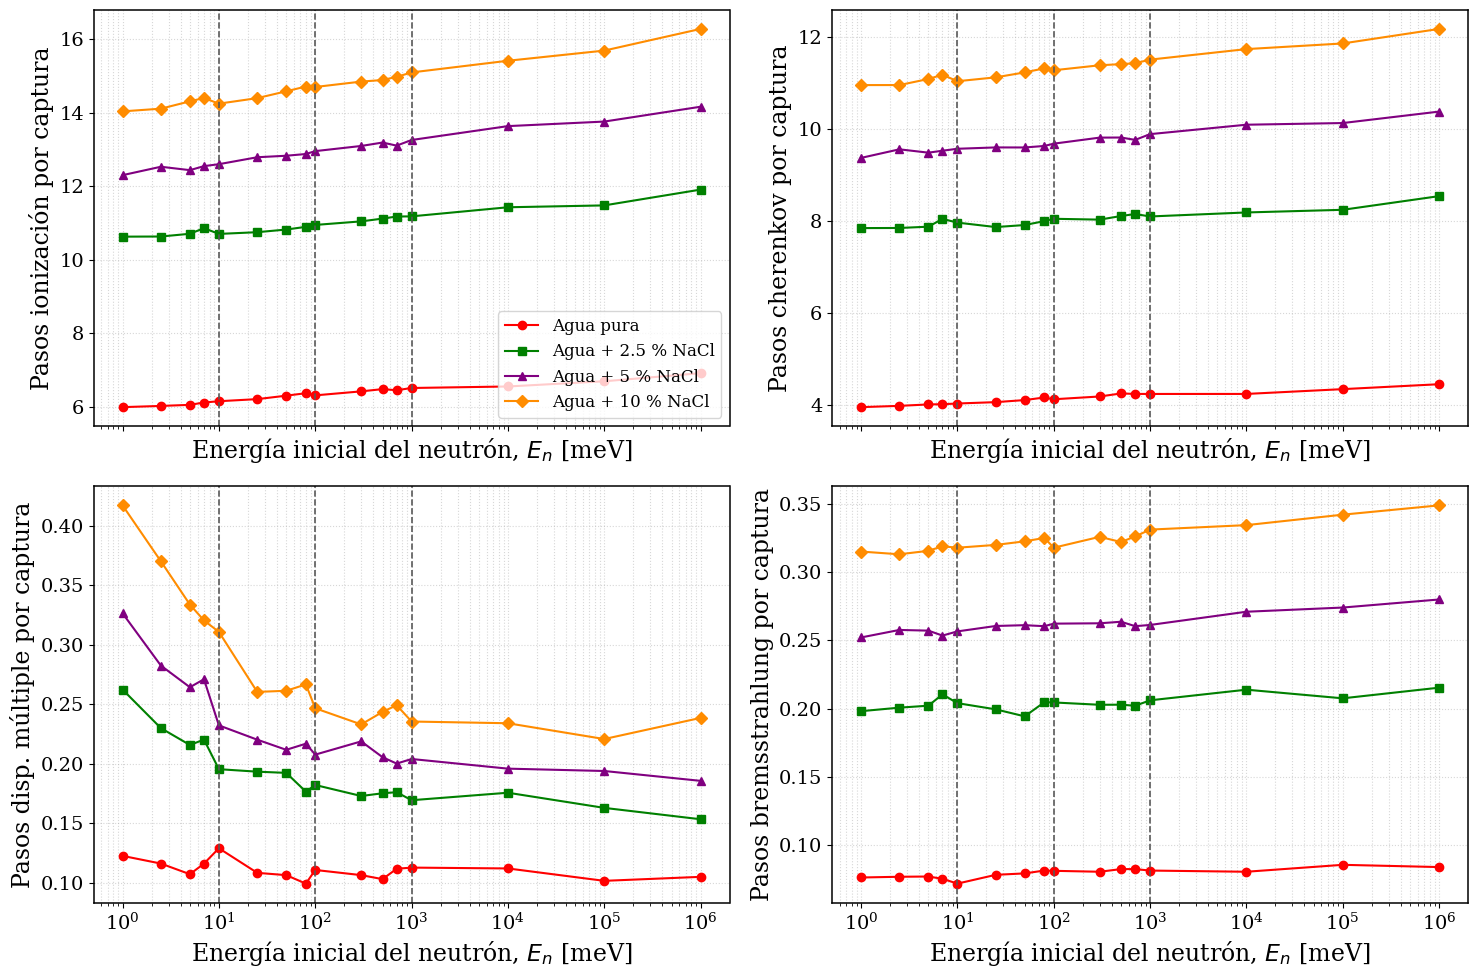

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
for ax, (p, n) in zip(axs.flat, PROC[:4]):
    for m in MEDIOS:
        ax.plot(VALOR_MEV, [conteo(e, m, p) / CAP[(e, m)] for e in ENERGIAS], MARCA[m] + "-", color=COLOR[m],
                label=NOMBRE[m])
    eje_energia(ax)
    regiones(ax)
    ax.set_ylabel(f"Pasos {n.lower()} por captura")
    ax.grid(True, which="both", ls=":", alpha=0.5)
axs[0, 0].legend()
fig.tight_layout()
guardar(fig, "fig_nueva_procesos_por_captura")

## Nueva: proceso que limita el paso según la energía del electrón

Fracción de los pasos del tanque limitados por cada proceso, en función de la energía del electrón tras el paso.
`G4Cerenkov` acorta los pasos cerca del umbral (para no cruzarlo) y a alta energía (número máximo de fotones por
paso); `eIoni` solo gana entre unos 0.4 y 1.3 MeV. Esto fija la forma de la Fig. 4.46.

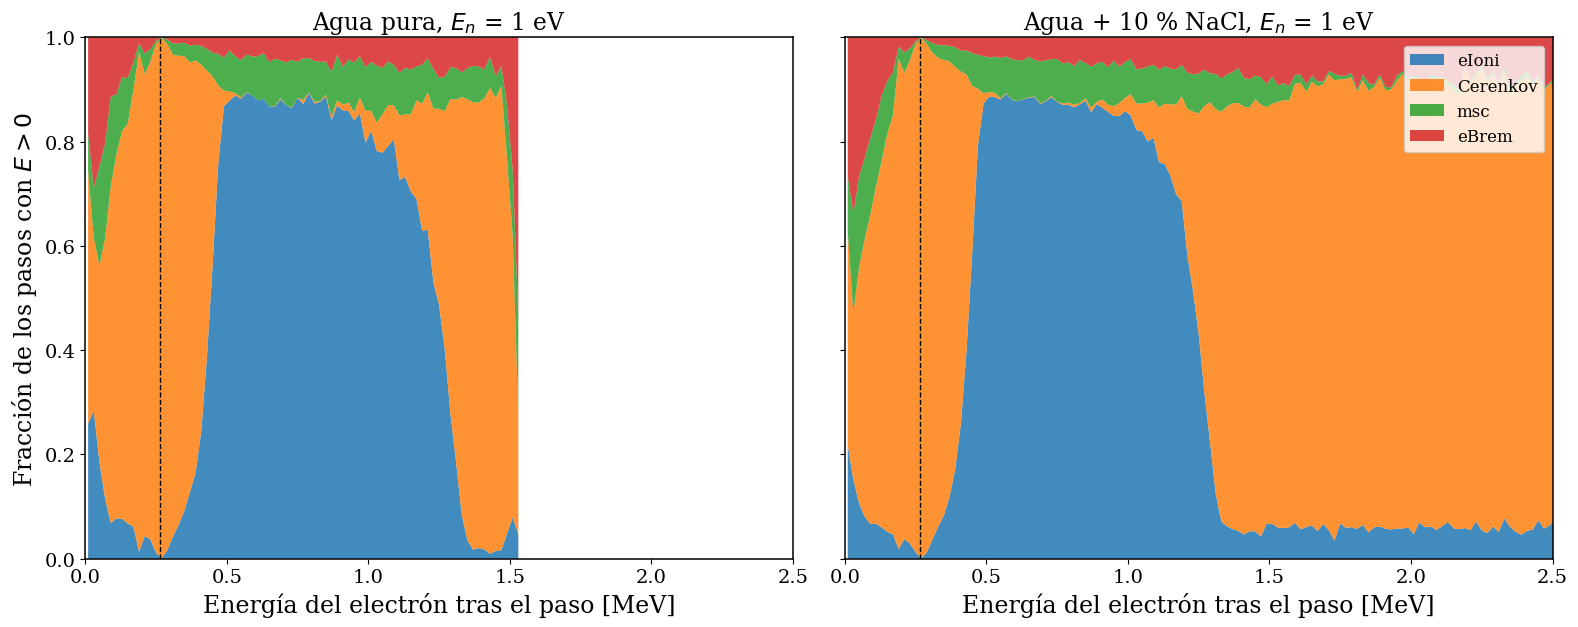

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)
for ax, m in zip(axs, ["Agua-pura", "Agua+10NaCl"]):
    H = R[("1000meV", m)]["histogramas"]
    x, ci = reagrupar(H["eIoni_E_no_nula_estricto"], 20)
    _, cc = reagrupar(H["Cerenkov_estricto"], 20)
    _, cb = reagrupar(H["eBrem_estricto"], 20)
    _, cm = reagrupar(H["msc_estricto"], 20)
    tot = ci + cc + cb + cm
    tot[tot < 30] = np.nan                     # intervalos con pocos pasos
    ax.stackplot(x, ci / tot, cc / tot, cm / tot, cb / tot, labels=["eIoni", "Cerenkov", "msc", "eBrem"],
                 colors=["tab:blue", "tab:orange", "tab:green", "tab:red"], alpha=0.85)
    ax.axvline(E_UMBRAL_AGUA, color="k", ls="--", lw=1)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Energía del electrón tras el paso [MeV]")
    ax.set_title(f"{NOMBRE[m]}, $E_n$ = 1 eV")
axs[0].set_ylabel("Fracción de los pasos con $E>0$")
axs[1].legend(loc="upper right")
fig.tight_layout()
guardar(fig, "fig_nueva_proceso_limitante")

## Fig. 4.46: energía de los pasos limitados por `eIoni`

Réplica de la figura de la tesis (100 intervalos de 16 keV entre 0 y 1.6 MeV, pasos `eIoni` con $E\neq0$ en el
tanque estricto). La curva no es el espectro de los electrones que ionizan ni la energía depositada: es la energía
tras los pasos que `eIoni` limitó. El máximo de un intervalo cambia entre 0.47 y 0.50 MeV de una energía a otra
por fluctuación estadística; con un suavizado de 50 keV queda en 0.48–0.50 MeV en todos los medios.

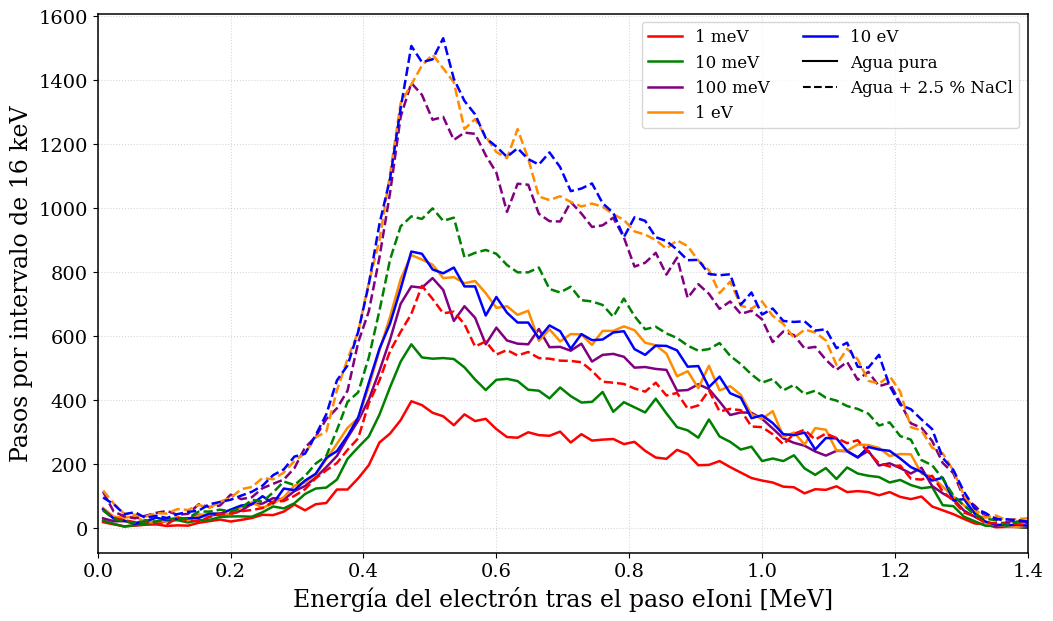

     E_n medio               máx. 16 keV  máx. suavizado   media
   1 meV Agua pura                 0.472           0.488   0.714
   1 meV Agua + 2.5 % NaCl         0.488           0.492   0.837
   1 meV Agua + 5 % NaCl           0.488           0.480   0.856
   1 meV Agua + 10 % NaCl          0.520           0.499   0.871
  10 meV Agua pura                 0.472           0.480   0.715
  10 meV Agua + 2.5 % NaCl         0.504           0.488   0.840
  10 meV Agua + 5 % NaCl           0.488           0.495   0.856
  10 meV Agua + 10 % NaCl          0.488           0.483   0.876
 100 meV Agua pura                 0.504           0.490   0.713
 100 meV Agua + 2.5 % NaCl         0.472           0.477   0.830
 100 meV Agua + 5 % NaCl           0.488           0.492   0.855
 100 meV Agua + 10 % NaCl          0.488           0.498   0.865
    1 eV Agua pura                 0.472           0.487   0.714
    1 eV Agua + 2.5 % NaCl         0.504           0.501   0.832
    1 eV Agua + 5 % NaCl 

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))
E_IONI = ["1meV", "10meV", "100meV", "1000meV", "10000meV"]          # energías de la figura de la tesis
for m, ls in [("Agua-pura", "-"), ("Agua+2.5NaCl", "--")]:
    for e in E_IONI:
        x, c = reagrupar(R[(e, m)]["histogramas"]["eIoni_E_no_nula_estricto"], 16)
        s = x < 1.6
        ax.plot(x[s], c[s], ls, color=COLOR_E[e], lw=1.8, label=f"{ROTULO[e]}" if m == "Agua-pura" else None)
ax.plot([], [], "k-", label="Agua pura")
ax.plot([], [], "k--", label="Agua + 2.5 % NaCl")
ax.set_xlim(0, 1.4)
ax.set_xlabel("Energía del electrón tras el paso eIoni [MeV]")
ax.set_ylabel("Pasos por intervalo de 16 keV")
ax.legend(ncol=2)
ax.grid(True, ls=":", alpha=0.5)
guardar(fig, "fig_4_46_pasos_eIoni")

filas = []
for e in E_IONI:
    for m in MEDIOS:
        h = R[(e, m)]["histogramas"]["eIoni_E_no_nula_estricto"]
        x, c = reagrupar(h, 16)
        c50 = np.convolve(h["conteos"], np.ones(50) / 50, "same")
        filas.append((ROTULO[e], NOMBRE[m], x[np.argmax(c[:100])], (np.argmax(c50) + 0.5) * h["ancho"], h["media"]))
print(f"{'E_n':>8s} {'medio':18s} {'máx. 16 keV':>12s} {'máx. suavizado':>15s} {'media':>7s}")
for f in filas:
    print(f"{f[0]:>8s} {f[1]:18s} {f[2]:12.3f} {f[3]:15.3f} {f[4]:7.3f}")

## Nueva: energía inicial de los $e^-$ y $e^+$

Energía tras el primer paso de cada traza que nace en el tanque, por captura, a $E_n$ = 1 eV. No es la energía de
producción (el archivo no registra el punto previo al primer paso): es una cota inferior. Por eso el máximo en
264 keV (primeros pasos que `G4Cerenkov` detiene en el umbral) y los cortes situados unos 0.5 MeV por debajo de los
bordes Compton de los fotones de captura más intensos ($T_\mathrm{max}=2E_\gamma^2/(m_ec^2+2E_\gamma)$, líneas
punteadas). El espectro de producción de los electrones Compton está en el informe de los fotones gamma.

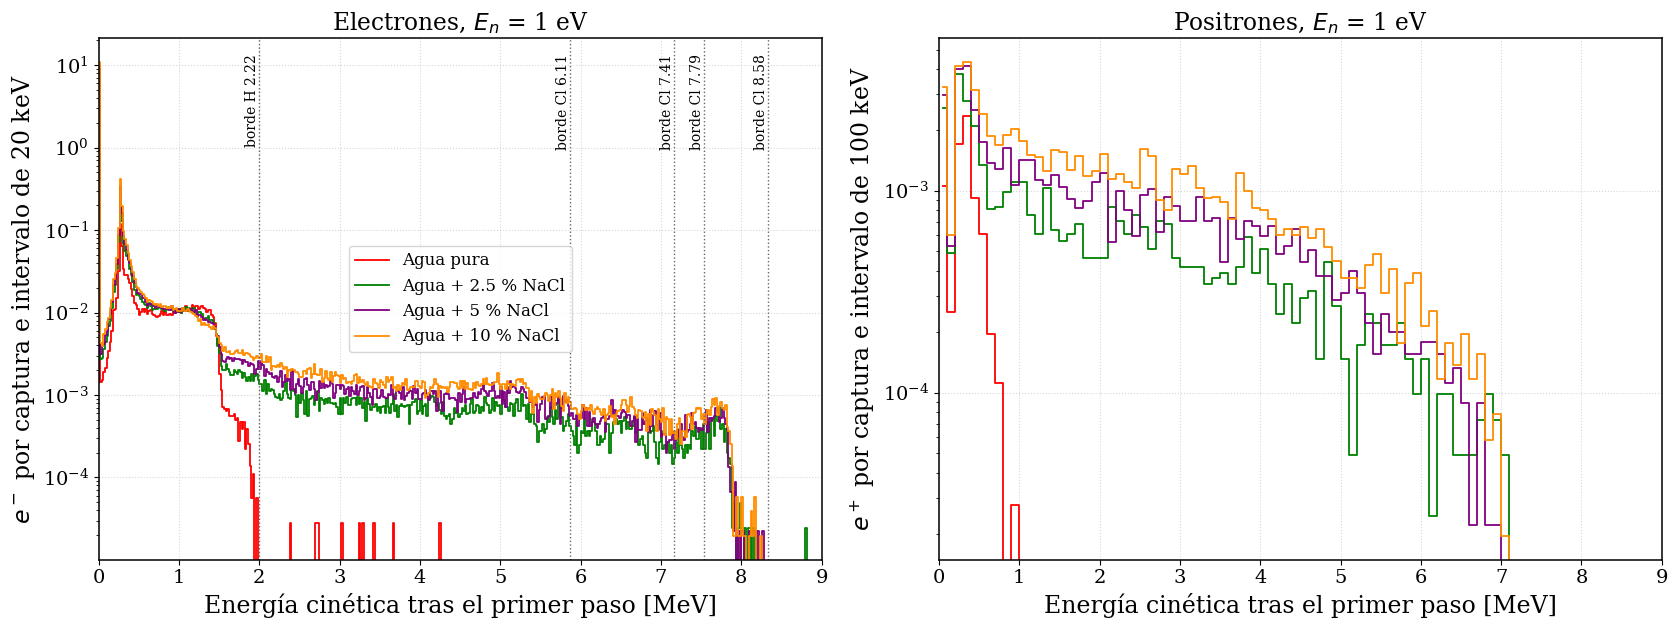

In [6]:
def borde(eg):
    return 2 * eg ** 2 / (0.51099895 + 2 * eg)


LINEAS = [(2.2246, "H 2.22"), (6.1109, "Cl 6.11"), (7.4140, "Cl 7.41"), (7.7901, "Cl 7.79"), (8.5784, "Cl 8.58")]
fig, axs = plt.subplots(1, 2, figsize=(17, 6.5))
for m in MEDIOS:
    for ax, p, k in [(axs[0], "e-", 4), (axs[1], "e+", 20)]:
        x, c = reagrupar(R[("1000meV", m)]["E_inicial"][p], k)
        ax.step(x, c / CAP[("1000meV", m)], where="mid", color=COLOR[m], lw=1.3, label=NOMBRE[m])
for eg, t in LINEAS:
    axs[0].axvline(borde(eg), color="0.4", ls=":", lw=1)
    axs[0].text(borde(eg), 0.97, f"borde {t}", rotation=90, va="top", ha="right", fontsize=10,
                transform=axs[0].get_xaxis_transform())
axs[0].set_ylabel("$e^-$ por captura e intervalo de 20 keV")
axs[1].set_ylabel("$e^+$ por captura e intervalo de 100 keV")
for ax, t in zip(axs, ["Electrones", "Positrones"]):
    ax.set_yscale("log")
    ax.set_xlim(0, 9)
    ax.set_xlabel("Energía cinética tras el primer paso [MeV]")
    ax.set_title(f"{t}, $E_n$ = 1 eV")
    ax.grid(True, ls=":", alpha=0.5)
axs[0].legend()
fig.tight_layout()
guardar(fig, "fig_nueva_energia_inicial")

## Nueva: espectro de los pasos `Cerenkov` cerca del umbral

`G4Cerenkov` acorta el paso para que el electrón termine justo sobre el umbral del material, por eso la energía
tras esos pasos se acumula en el umbral. En la Campaña 1 el agua de los cuatro medios usa la tabla `waterPT1`
($n=1.33$ constante): umbral 264.06 keV. El segundo máximo, 186.2 keV, es el umbral del Pyrex del PMT ($n=1.47$).
Las líneas punteadas son los umbrales de la Tabla 4.17 (índices de la literatura), que la simulación no usó.

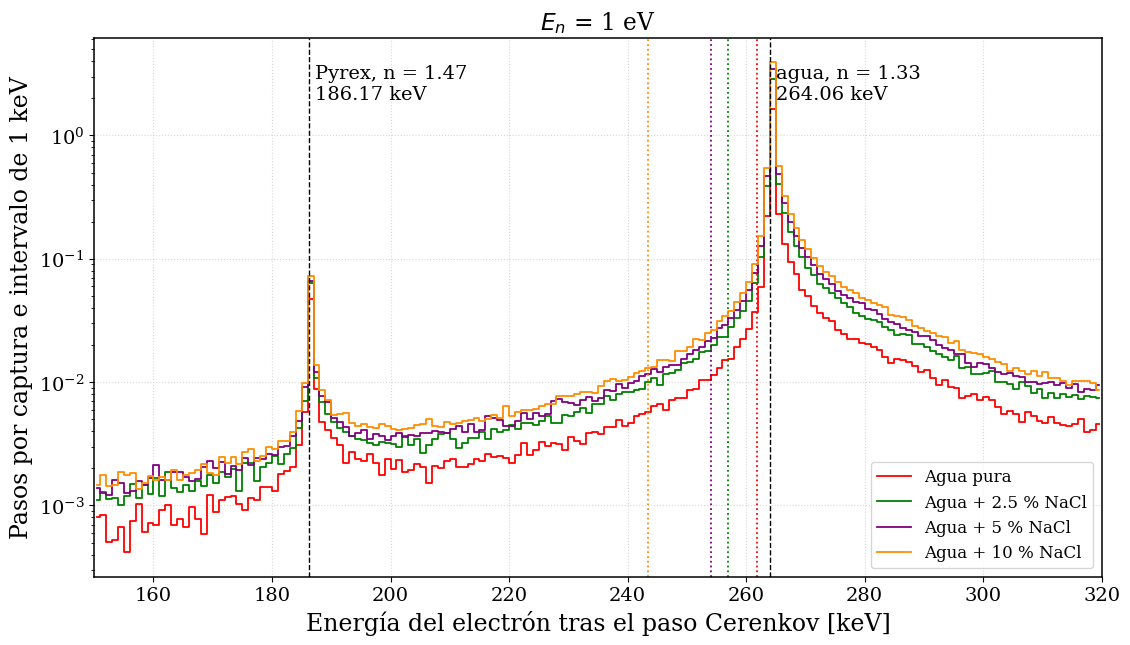

In [7]:
fig, ax = plt.subplots(figsize=(13, 7))
for m in MEDIOS:
    x, c = reagrupar(R[("1000meV", m)]["histogramas"]["Cerenkov_umbral_estricto"], 25)
    ax.step(x * 1e3, c / CAP[("1000meV", m)], where="mid", color=COLOR[m], lw=1.3, label=NOMBRE[m])
    ax.axvline(umbral_cherenkov(N_TESIS[m]) * 1e3, color=COLOR[m], ls=":", lw=1.3)
ax.axvline(E_UMBRAL_AGUA * 1e3, color="k", ls="--", lw=1)
ax.axvline(E_UMBRAL_PYREX * 1e3, color="k", ls="--", lw=1)
ax.text(E_UMBRAL_AGUA * 1e3 + 1, 0.95, "agua, n = 1.33\n264.06 keV", transform=ax.get_xaxis_transform(), va="top")
ax.text(E_UMBRAL_PYREX * 1e3 + 1, 0.95, "Pyrex, n = 1.47\n186.17 keV", transform=ax.get_xaxis_transform(), va="top")
ax.set_yscale("log")
ax.set_xlim(150, 320)
ax.set_xlabel("Energía del electrón tras el paso Cerenkov [keV]")
ax.set_ylabel("Pasos por captura e intervalo de 1 keV")
ax.set_title("$E_n$ = 1 eV")
ax.legend(loc="lower right")
ax.grid(True, ls=":", alpha=0.5)
guardar(fig, "fig_nueva_umbral_cherenkov")

## Fig. 4.47 y Tabla 4.18: ajuste fino del máximo Cherenkov

Gaussiana más fondo lineal en ±4.5 keV alrededor del intervalo más poblado (intervalos de 0.04 keV), como en la
tesis, para las cinco energías y los cuatro medios. Los ajustes dan 264.085–264.088 keV en todos los casos: el
máximo no depende del medio porque el índice de refracción es el mismo.

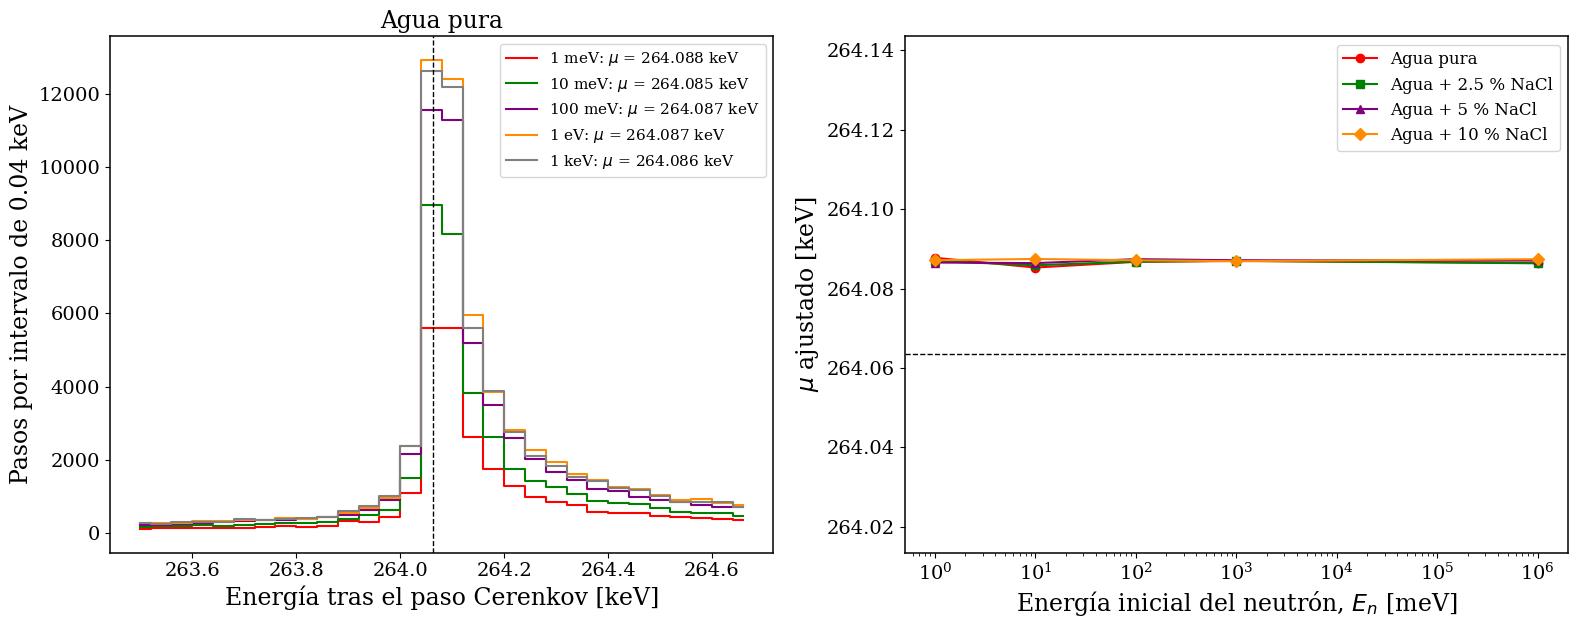

Agua pura            1 meV  mu = 264.0878 ± 0.0013 keV   sigma = 0.0433 keV
Agua pura           10 meV  mu = 264.0853 ± 0.0013 keV   sigma = 0.0414 keV
Agua pura          100 meV  mu = 264.0867 ± 0.0013 keV   sigma = 0.0423 keV
Agua pura             1 eV  mu = 264.0870 ± 0.0013 keV   sigma = 0.0428 keV
Agua pura            1 keV  mu = 264.0865 ± 0.0013 keV   sigma = 0.0425 keV
Agua + 2.5 % NaCl    1 meV  mu = 264.0870 ± 0.0013 keV   sigma = 0.0430 keV
Agua + 2.5 % NaCl   10 meV  mu = 264.0859 ± 0.0013 keV   sigma = 0.0419 keV
Agua + 2.5 % NaCl  100 meV  mu = 264.0868 ± 0.0013 keV   sigma = 0.0427 keV
Agua + 2.5 % NaCl     1 eV  mu = 264.0870 ± 0.0013 keV   sigma = 0.0431 keV
Agua + 2.5 % NaCl    1 keV  mu = 264.0864 ± 0.0013 keV   sigma = 0.0422 keV
Agua + 5 % NaCl      1 meV  mu = 264.0866 ± 0.0014 keV   sigma = 0.0431 keV
Agua + 5 % NaCl     10 meV  mu = 264.0864 ± 0.0013 keV   sigma = 0.0428 keV
Agua + 5 % NaCl    100 meV  mu = 264.0874 ± 0.0014 keV   sigma = 0.0436 keV
Agua + 5 % N

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6.5))
x0 = E_UMBRAL_AGUA * 1e3
for e in E5:
    h = R[(e, "Agua-pura")]["histogramas"]["Cerenkov_umbral_estricto"]
    x = centros(h) * 1e3
    s = np.abs(x - x0) < 0.6
    mu, u, sg = ajuste_pico_cherenkov(h)
    axs[0].step(x[s], np.array(h["conteos"])[s], where="mid", color=COLOR_E[e],
                label=f"{ROTULO[e]}: $\\mu$ = {mu * 1e3:.3f} keV")
axs[0].axvline(x0, color="k", ls="--", lw=1)
axs[0].set_xlabel("Energía tras el paso Cerenkov [keV]")
axs[0].set_ylabel("Pasos por intervalo de 0.04 keV")
axs[0].set_title("Agua pura")
axs[0].legend(fontsize=11)
tabla = []
for m in MEDIOS:
    mus = []
    for e in E5:
        mu, u, sg = ajuste_pico_cherenkov(R[(e, m)]["histogramas"]["Cerenkov_umbral_estricto"])
        mus.append(mu * 1e3)
        tabla.append((NOMBRE[m], ROTULO[e], mu * 1e3, u * 1e3, sg * 1e3))
    axs[1].plot(VALOR_MEV[[0, 4, 8, 12, 15]], mus, MARCA[m] + "-", color=COLOR[m], label=NOMBRE[m])
axs[1].axhline(x0, color="k", ls="--", lw=1)
eje_energia(axs[1])
axs[1].set_ylabel(r"$\mu$ ajustado [keV]")
axs[1].set_ylim(x0 - 0.05, x0 + 0.08)
axs[1].legend()
fig.tight_layout()
guardar(fig, "fig_4_47_ajuste_fino_cherenkov")
for t in tabla:
    print(f"{t[0]:18s} {t[1]:>7s}  mu = {t[2]:.4f} ± {t[3]:.4f} keV   sigma = {t[4]:.4f} keV")

## Nueva: dónde ocurren los pasos Cherenkov del Pyrex

Los pasos `Cerenkov` con energía en 180–190 keV (umbral del Pyrex) se concentran a $z\approx1180$ mm y
$r\lesssim100$ mm, en el domo del PMT; los del agua se reparten por el volumen.

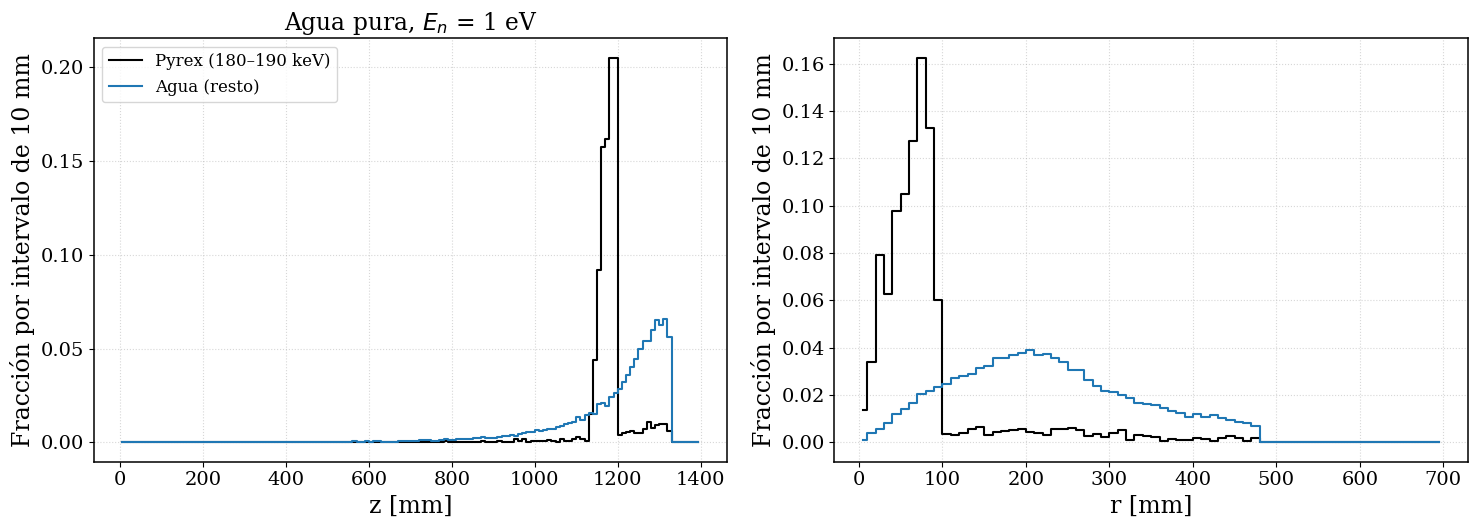

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5))
for k, ax in zip(["z", "r"], axs):
    for etiqueta, clave, col in [("Pyrex (180–190 keV)", "Cerenkov_pyrex_posicion", "k"),
                                 ("Agua (resto)", "Cerenkov_agua_posicion", "tab:blue")]:
        h = R[("1000meV", "Agua-pura")][clave][k]
        c = np.array(h["conteos"], float)
        ax.step(centros(h), c / c.sum(), where="mid", color=col, label=etiqueta)
    ax.set_xlabel(f"{k} [mm]")
    ax.set_ylabel("Fracción por intervalo de 10 mm")
    ax.grid(True, ls=":", alpha=0.5)
axs[0].legend()
axs[0].set_title("Agua pura, $E_n$ = 1 eV")
fig.tight_layout()
guardar(fig, "fig_nueva_posicion_pyrex")

## Nueva: rendimientos por captura

Trazas de $e^-$ y $e^+$, electrones que nacen sobre el umbral del agua, trazas con algún paso `Cerenkov` y
longitud registrada sobre el umbral (sin el primer paso), por captura.

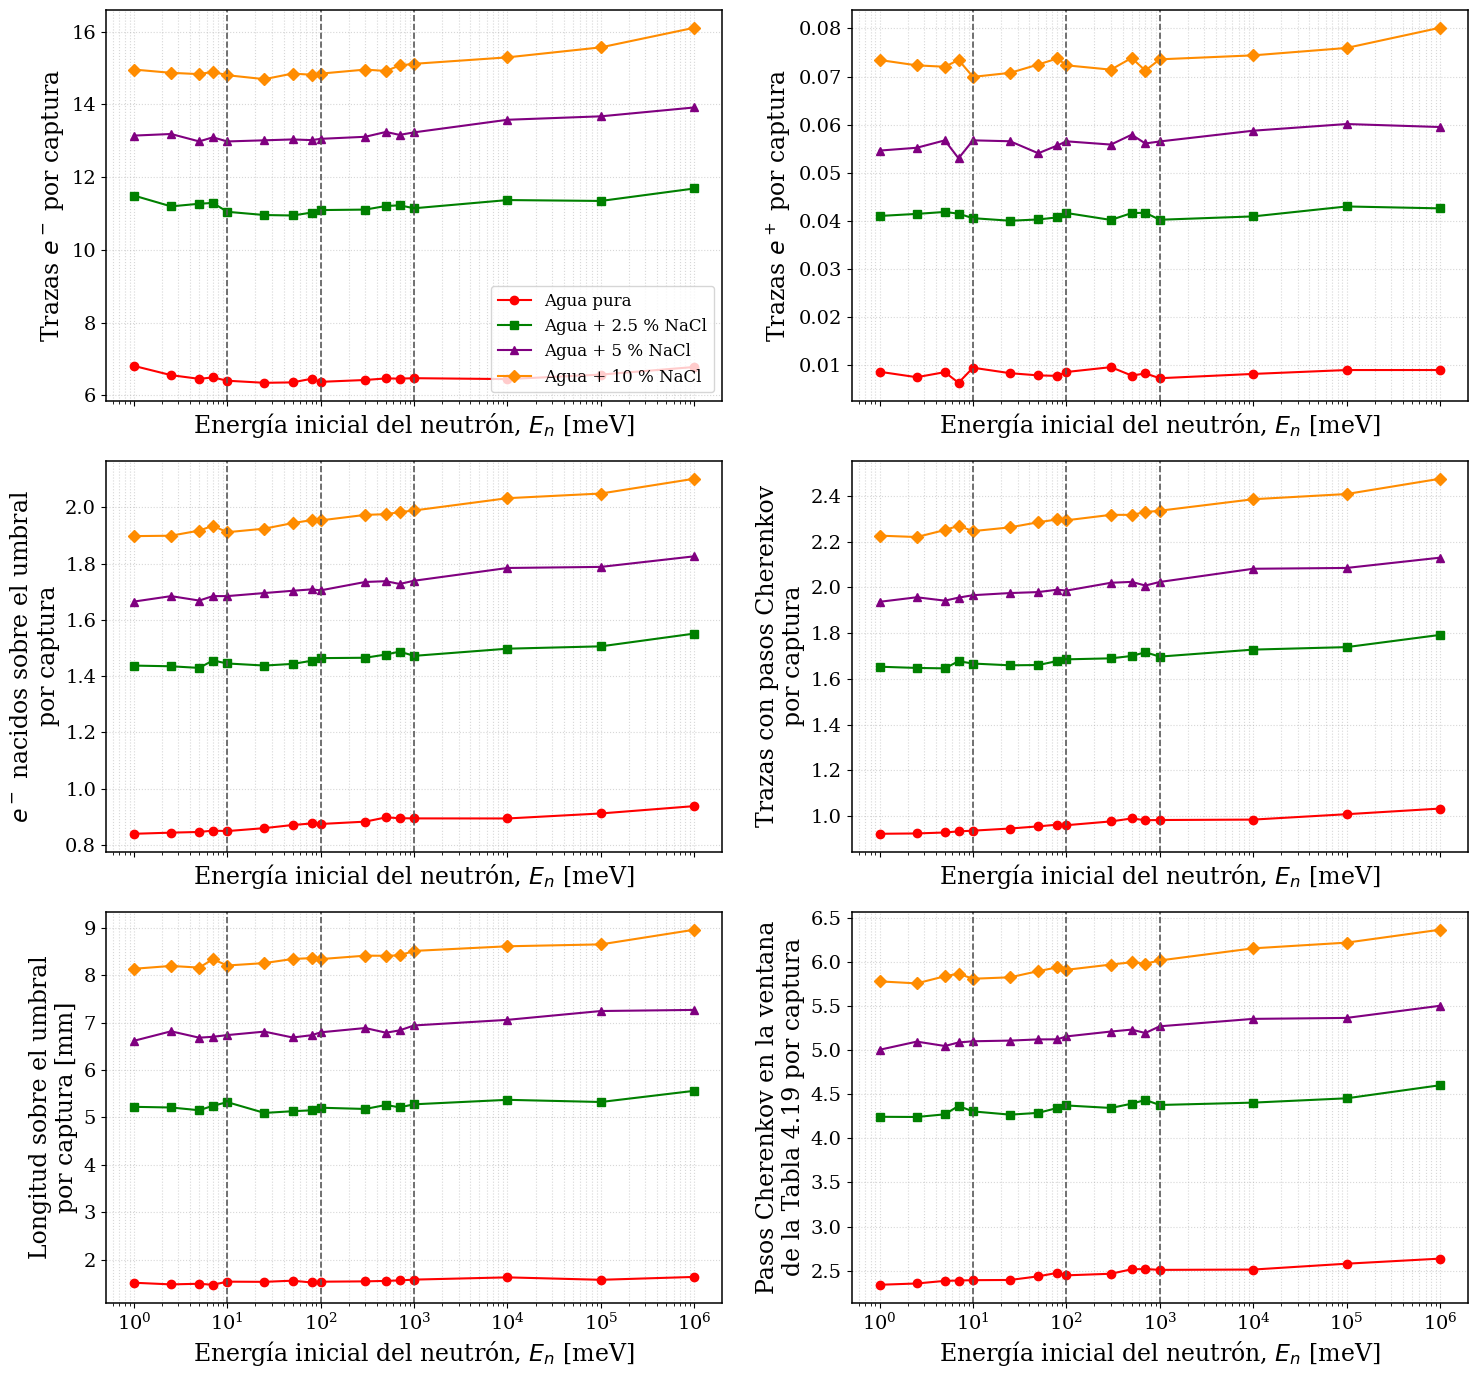

In [10]:
def por_cap(f):
    return lambda m: [f(R[(e, m)]) / CAP[(e, m)] for e in ENERGIAS]


PANELES = [
    (por_cap(lambda r: r["trazas"]["e-"]), "Trazas $e^-$ por captura"),
    (por_cap(lambda r: r["trazas"]["e+"]), "Trazas $e^+$ por captura"),
    (por_cap(lambda r: r["trazas_sobre_umbral_tanque"]["e-"]), "$e^-$ nacidos sobre el umbral\npor captura"),
    (por_cap(lambda r: r["trazas_emisoras"]["e-"] + r["trazas_emisoras"]["e+"]), "Trazas con pasos Cherenkov\npor captura"),
    (por_cap(lambda r: r["longitud_sobre_umbral_mm"]), "Longitud sobre el umbral\npor captura [mm]"),
    (por_cap(lambda r: r["ventanas_Cerenkov"]["tesis_agua"]), "Pasos Cherenkov en la ventana\nde la Tabla 4.19 por captura"),
]
fig, axs = plt.subplots(3, 2, figsize=(15, 14), sharex=True)
for ax, (f, yl) in zip(axs.flat, PANELES):
    for m in MEDIOS:
        ax.plot(VALOR_MEV, f(m), MARCA[m] + "-", color=COLOR[m], label=NOMBRE[m])
    eje_energia(ax)
    regiones(ax)
    ax.set_ylabel(yl)
    ax.grid(True, which="both", ls=":", alpha=0.5)
axs[0, 0].legend()
fig.tight_layout()
guardar(fig, "fig_nueva_rendimientos_por_captura")

## Figs. E.3 y E.4: energía de todos los pasos de los $e^\pm$ en el tanque

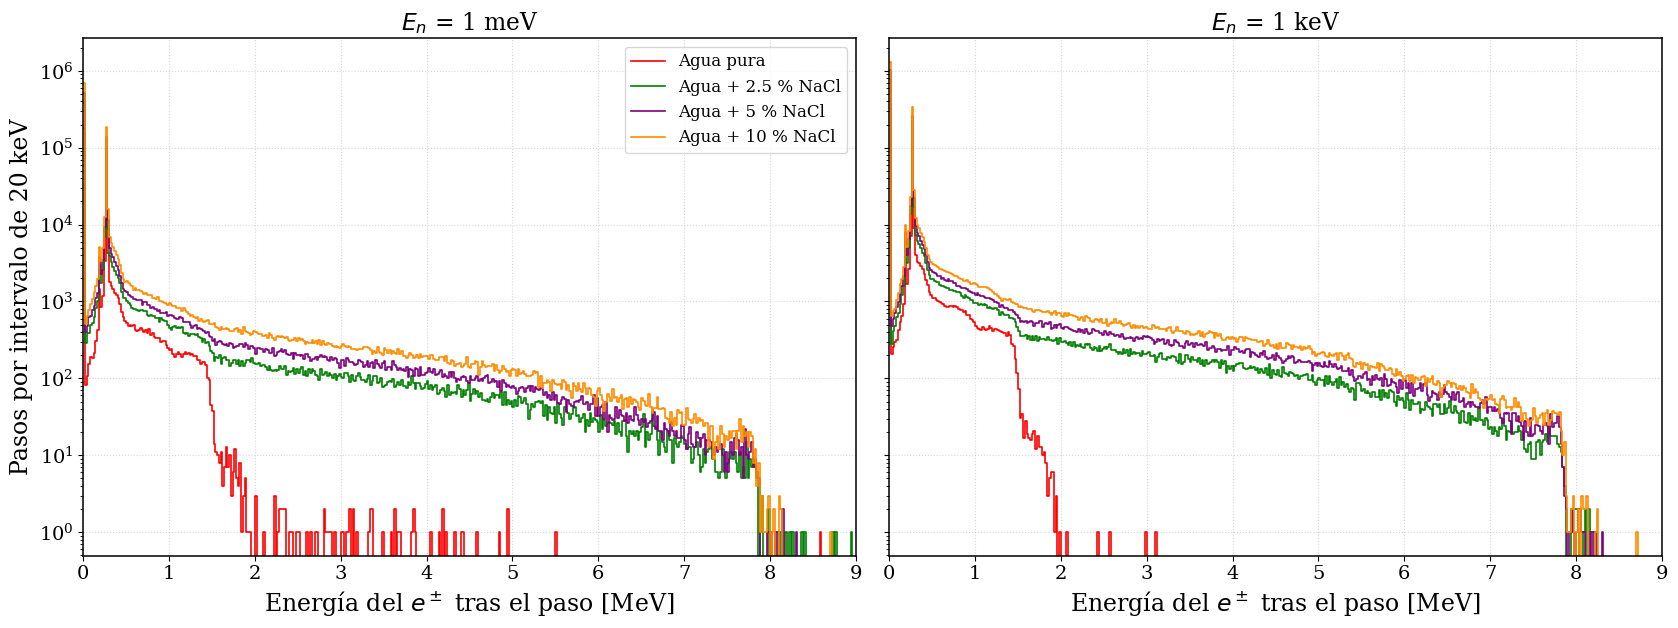

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(17, 6.5), sharey=True)
for ax, e in zip(axs, ["1meV", "1000000meV"]):
    for m in MEDIOS:
        x, c = reagrupar(R[(e, m)]["histogramas"]["pasos_tanque"], 4)
        ax.step(x, c, where="mid", color=COLOR[m], lw=1.2, label=NOMBRE[m])
    ax.set_yscale("log")
    ax.set_xlim(0, 9)
    ax.set_xlabel("Energía del $e^\\pm$ tras el paso [MeV]")
    ax.set_title(f"$E_n$ = {ROTULO[e]}")
    ax.grid(True, ls=":", alpha=0.5)
axs[0].set_ylabel("Pasos por intervalo de 20 keV")
axs[0].legend()
fig.tight_layout()
guardar(fig, "fig_E3_E4_pasos_tanque")

## Verificación frente a la tesis

In [12]:
with open(RES / "verificacion_tesis_electrones.tsv") as f:
    V = list(csv.DictReader(f, delimiter="\t"))
n = {k: sum(1 for v in V if v["estado"] == k) for k in ("igual", "compatible", "difiere", "sin valor en la tesis")}
print(f"{n['igual']} iguales, {n['compatible']} compatibles, {n['difiere']} distintas, "
      f"{n['sin valor en la tesis']} sin valor en la tesis")
for v in V:
    if v["estado"] == "difiere":
        print(f"  {v['magnitud']:44s} {v['energia']:>11s} {v['medio']:13s} tesis {v['tesis']:>7s}  reproducido {v['reproducido']}")

118 iguales, 20 compatibles, 14 distintas, 7 sin valor en la tesis
  Tabla E.1 msc                                       1meV Agua+2.5NaCl  tesis    4091  reproducido 5415
  Tabla E.1 msc                                       1meV Agua+5NaCl    tesis    5911  reproducido 7652
  Tabla E.1 eBrem                                     1meV Agua+2.5NaCl  tesis    5415  reproducido 4091
  Tabla E.1 eBrem                                     1meV Agua+5NaCl    tesis    7652  reproducido 5911
  Tabla E.1 msc                                     100meV Agua-pura     tesis    2132  reproducido 3668
  Tabla E.1 eBrem                                   100meV Agua-pura     tesis    3668  reproducido 2694
  Tabla E.1 eBrem                                   100meV Agua+10NaCl   tesis    8858  reproducido 15765
  Tabla E.1 Transportation                          100meV Agua+2.5NaCl  tesis     240  reproducido 504
  Fig. 4.46 máximo del espectro eIoni (MeV)           1meV Agua+2.5NaCl  tesis   0.492  repro